In [1]:
import pandas as pd
import warnings
import numpy as np
warnings.filterwarnings("ignore")

## Estrazione dati da MongoDB

In [2]:
from pymongo import MongoClient
from dotenv import load_dotenv
import os

In [3]:
load_dotenv()
MONGO_URI = os.getenv("MONGO_URI")

client = MongoClient(MONGO_URI)
db=client["PolymerPrediction"]
collection=db["bicerano_tg"]

print(collection.count_documents({}))

304


In [4]:
docs = list(collection.find({}))
df = pd.DataFrame(docs)

# espando il dizionario "properties"
prop_df = pd.json_normalize(df["properties"])

# integro nel dataframe
df = pd.concat([df.drop(columns=["properties"]), prop_df], axis=1)

# rimuovo righe senza SMILES o Tg
df = df.dropna(subset=["smiles", "Tg"])

df.head()


,_id,polymer_name,smiles,bigsmiles,source_dataset,Tg,density
0,693593c290fac38508f81563,Poly[oxy(diethylsilylene)],*O[Si](*)(CC)CC,{<O[Si](CC)(CC)>},Bicerano_bigsmiles,130,None
1,693593c290fac38508f81564,Poly(dimethyl siloxane),*O[Si](*)(C)C,{<O[Si](C)(C)>},Bicerano_bigsmiles,152,None
2,693593c290fac38508f81565,Poly(3-butoxypropylene oxide),*CC(COCCCC)O*,"{<CC(COCCCC)O>,<C(COCCCC)CO>}",Bicerano_bigsmiles,194,None
3,693593c290fac38508f81566,Poly(4-cyclohexyl-1-butene),*CC(*)CCC1CCCCC1,{$CC(CCC1CCCCC1)$},Bicerano_bigsmiles,313,None
4,693593c290fac38508f81567,Poly[(pentafluoroethyl)ethylene],*CC(*)C(F)(F)C(F)(F)F,{$CC(C(F)(F)C(F)(F)F)$},Bicerano_bigsmiles,314,None


## Integrazione descrittori RDKit

In [5]:
from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit.ML.Descriptors import MoleculeDescriptors
import numpy as np

descriptor_names = [desc[0] for desc in Descriptors._descList]
calc = MoleculeDescriptors.MolecularDescriptorCalculator(descriptor_names)
# print(descriptor_names)

def rdkit_descr(smi):
    mol = Chem.MolFromSmiles(str(smi))
    if mol is None:
        return {d: np.nan for d in descriptor_names}
    values = calc.CalcDescriptors(mol)
    return dict(zip(descriptor_names, values))

desc_df = df["smiles"].apply(rdkit_descr).apply(pd.Series)
desc_df.head()

,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,5.736111,5.736111,0.266451,-0.810185,0.490580,16.333333,102.209,92.129,102.050091,36.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,5.437500,5.437500,0.283951,-0.770062,0.416300,18.500000,74.155,68.107,74.018791,24.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,5.472963,5.472963,0.131212,0.131212,0.487422,16.555556,130.187,116.075,130.099380,54.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,1.728889,1.728889,0.704974,0.704974,0.555925,27.200000,138.254,120.110,138.140851,58.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,12.301991,12.301991,0.173125,-5.311759,0.524716,20.555556,146.058,143.034,146.015491,54.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Aggiunta Fingerprint

In [6]:
from rdkit.Chem import rdFingerprintGenerator

morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=1024)

def morgan_fp(smiles):
    mol = Chem.MolFromSmiles(str(smiles))
    if mol is None:
        return [0]*1024
    fp = morgan_gen.GetFingerprint(mol)  
    return list(fp)

fp_df = df["smiles"].apply(morgan_fp).apply(pd.Series)
fp_df.columns = [f"fp_{i}" for i in range(fp_df.shape[1])]

In [7]:
from rdkit.Chem import MACCSkeys

def maccs_fp(smiles):
    mol = Chem.MolFromSmiles(str(smiles))
    if mol is None:
        return [0]*167  # MACCS ha 167 bit (indice 0 inutilizzato)
    fp = MACCSkeys.GenMACCSKeys(mol)
    return list(fp)
maccs_df = df["smiles"].apply(maccs_fp).apply(pd.Series)
maccs_df.columns=[f"maccs_{i}" for i in range(167)]

feature_df = pd.concat([desc_df, fp_df, maccs_df], axis=1)

## Pulizia dei dati

In [8]:
feature_df = feature_df.replace([np.inf, -np.inf], np.nan)
feature_df = feature_df.fillna(feature_df.median(numeric_only=True))
feature_df = feature_df.dropna(axis=1, how="all")

# --- rimuovo colonne costanti (con varianza 0) 
from sklearn.feature_selection import VarianceThreshold

sel = VarianceThreshold(threshold=0.0)
sel.fit(feature_df)

mask = sel.get_support()
feature_df = feature_df.loc[:, mask]

print("Shape:", feature_df.shape[1])


Shape: 960


## Preparazione dataset (separazione target)

In [9]:
y = df["Tg"]
X = feature_df.copy()
X.index = df["_id"]
print("Shape X:", X.shape)
print("Shape y:", y.shape)
X.sample(10)

Shape X: (304, 960)
Shape y: (304,)


,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,...,maccs_156,maccs_157,maccs_158,maccs_159,maccs_160,maccs_161,maccs_162,maccs_163,maccs_164,maccs_165
_id,,,,,,,,,,,,,,,,,,,,,
693593c290fac38508f8159e,2.389861,2.389861,0.520933,0.520933,0.628798,17.833333,160.260,144.132,160.125201,64.0,...,0,0,0,0,1,0,1,1,0,1
693593c290fac38508f815d6,11.745513,11.745513,0.001204,-0.045792,0.503144,17.083333,162.188,152.108,162.068080,62.0,...,0,1,0,1,1,0,1,1,1,1
693593c290fac38508f81639,6.290273,6.290273,0.000785,0.000785,0.185373,11.652174,590.682,564.474,590.199428,216.0,...,1,1,0,1,0,1,1,1,1,1
693593c290fac38508f815e2,10.995961,10.995961,0.048756,-0.383675,0.816386,13.166667,240.258,228.162,240.078644,90.0,...,0,1,0,1,1,0,1,1,1,1
693593c290fac38508f81616,11.389536,11.389536,0.137554,0.137554,0.406089,14.538462,184.279,164.119,184.146330,76.0,...,0,1,0,1,1,0,0,0,1,0
693593c290fac38508f81670,2.342214,2.342214,0.705417,0.705417,0.506847,18.714286,98.189,84.077,98.109550,42.0,...,0,0,0,0,1,0,0,0,0,0
693593c290fac38508f815f1,5.900854,5.900854,0.480860,0.480860,0.610719,15.800000,152.624,143.552,152.039278,52.0,...,0,0,0,0,1,0,1,1,0,1
693593c290fac38508f815bd,2.572083,2.572083,0.388187,-0.388187,0.476370,16.333333,100.237,88.141,100.070827,36.0,...,0,0,0,0,1,0,0,0,0,0
693593c290fac38508f8165f,11.497457,11.497457,0.128702,0.128702,0.433548,17.500000,170.252,152.108,170.130680,70.0,...,0,1,0,1,1,0,0,0,1,0


## Gradient Boosting
Anche se le colonne sono ancora tante, per farsi un'idea

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score

random_state=24

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=random_state)

model_base = GradientBoostingRegressor(random_state=random_state)
model_base.fit(X_train, y_train)

pred_base = model_base.predict(X_test)

print("MAE:", mean_absolute_error(y_test, pred_base))
print("R2:", r2_score(y_test, pred_base))


MAE: 26.749855897408608
R2: 0.8653649003416028


## Cross validation

Per la validazione incrociata uso 5-fold CV, poiché rappresenta il miglior compromesso tra stabilità della stima e quantità di dati utilizzata per l’addestramento. Con dataset piccoli e un numero elevato di feature (come in questo caso), un numero maggiore di fold aumenterebbe la varianza delle performance e renderebbe il modello più instabile. 

In [11]:
from sklearn.model_selection import GridSearchCV, KFold

param_grid = {
    "n_estimators": [200, 400, 800],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [2, 3, 4],
    "subsample": [0.8, 1.0]
}

gb_model = GradientBoostingRegressor(random_state=random_state)

# Cross-validation 5 fold
cv = KFold(n_splits=5, shuffle=True, random_state=random_state)

# Grid search
grid_search = GridSearchCV(
    estimator=gb_model,
    param_grid=param_grid,
    scoring="neg_mean_absolute_error",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

# Risultati tuning
print("Best parameters found:")
print(grid_search.best_params_)

print("\nBest CV MAE:")
print(-grid_search.best_score_)

# 8. Valutazione finale su test set
best_model = grid_search.best_estimator_
pred = best_model.predict(X_test)

mae = mean_absolute_error(y_test, pred)
r2 = r2_score(y_test, pred)

print("\nPerformance on Test Set:")
print(f"MAE: {mae}")
print(f"R² : {r2}")

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best parameters found:
{'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 800, 'subsample': 0.8}

Best CV MAE:
23.362768817190222

Performance on Test Set:
MAE: 27.525009058661716
R² : 0.8638805521443542


## Feature selection

In [15]:
from sklearn.feature_selection import mutual_info_regression

mi_scores = mutual_info_regression(X, y)
mi_series = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)

# selezioniamo le top N feature
N = 300
top_features_mi = mi_series.head(N).index

X_mi_selected = X[top_features_mi]
print(X_mi_selected.shape)
print(X.shape)
print("Feature scelte (MI):", len(top_features_mi))

(304, 300)
(304, 960)
Feature scelte (MI): 300


In [17]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score

X_train, X_test, y_train, y_test = train_test_split(
    X_mi_selected, y, test_size=0.2, random_state=random_state
)

model_mi = GradientBoostingRegressor(random_state=random_state)
model_mi.fit(X_train, y_train)

pred_mi = model_mi.predict(X_test)

print("MAE:", mean_absolute_error(y_test, pred_mi))
print("R²:", r2_score(y_test, pred_mi))


MAE: 29.38402532044476
R²: 0.8406548278061199


In [22]:
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

perm = permutation_importance(model_mi, X_mi_selected, y, n_repeats=10, random_state=random_state)
perm_series = pd.Series(perm.importances_mean, index=X_mi_selected.columns)
perm_series = perm_series.sort_values(ascending=False)

thr = perm_series.mean()   
selected = perm_series[perm_series > thr].index

X_perm_selected = X_mi_selected[selected]

print("Feature scelte (Permutation Importance):", X_perm_selected.shape)


Feature scelte (Permutation Importance): (304, 29)


In [21]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score

X_train, X_test, y_train, y_test = train_test_split(
    X_perm_selected, y, test_size=0.2, random_state=random_state
)

model_perm = GradientBoostingRegressor(random_state=random_state)
model_perm.fit(X_train, y_train)

pred_perm = model_perm.predict(X_test)

print("MAE:", mean_absolute_error(y_test, pred_perm))
print("R²:", r2_score(y_test, pred_perm))


MAE: 29.6180664018833
R²: 0.8413405264658833


### Univariate regression - Analisi dei descrittori (solo per esplorazione)

In [31]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

scores = []

for col in X.columns:
    X_col = X[[col]]  # solo 1 descrittore
    
    # split
    X_train, X_test, y_train, y_test = train_test_split(
        X_col, y, test_size=0.2, random_state=random_state
    )
    
    # modello semplice (va benissimo RF)
    model = RandomForestRegressor(n_estimators=200, random_state=random_state)
    model.fit(X_train, y_train)
    
    pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, pred)
    r2 = r2_score(y_test, pred)
    
    scores.append({
        "feature": col,
        "MAE": mae,
        "R2": r2
    })

import pandas as pd
results = pd.DataFrame(scores)
results_sorted = results.sort_values("MAE")
results_sorted.head(20)

,feature,MAE,R2
1037,RingCount,40.571198,0.808170
1007,Chi0,44.037406,0.719048
1018,HallKierAlpha,44.198970,0.729439
1024,SlogP_VSA6,47.101670,0.737393
1004,AvgIpc,47.935677,0.680306
1039,fr_benzene,48.784396,0.726035
1033,NumAromaticCarbocycles,48.784396,0.726035
1028,VSA_EState6,49.280717,0.679731
1034,NumAromaticRings,50.259014,0.694608
1022,SMR_VSA7,50.544168,0.681307


In [32]:
results.sort_values("R2", ascending=False).head(20)

,feature,MAE,R2
1037,RingCount,40.571198,0.808170
1024,SlogP_VSA6,47.101670,0.737393
1018,HallKierAlpha,44.198970,0.729439
1033,NumAromaticCarbocycles,48.784396,0.726035
1039,fr_benzene,48.784396,0.726035
1007,Chi0,44.037406,0.719048
1034,NumAromaticRings,50.259014,0.694608
1030,FractionCSP3,51.338951,0.684397
1022,SMR_VSA7,50.544168,0.681307
1004,AvgIpc,47.935677,0.680306


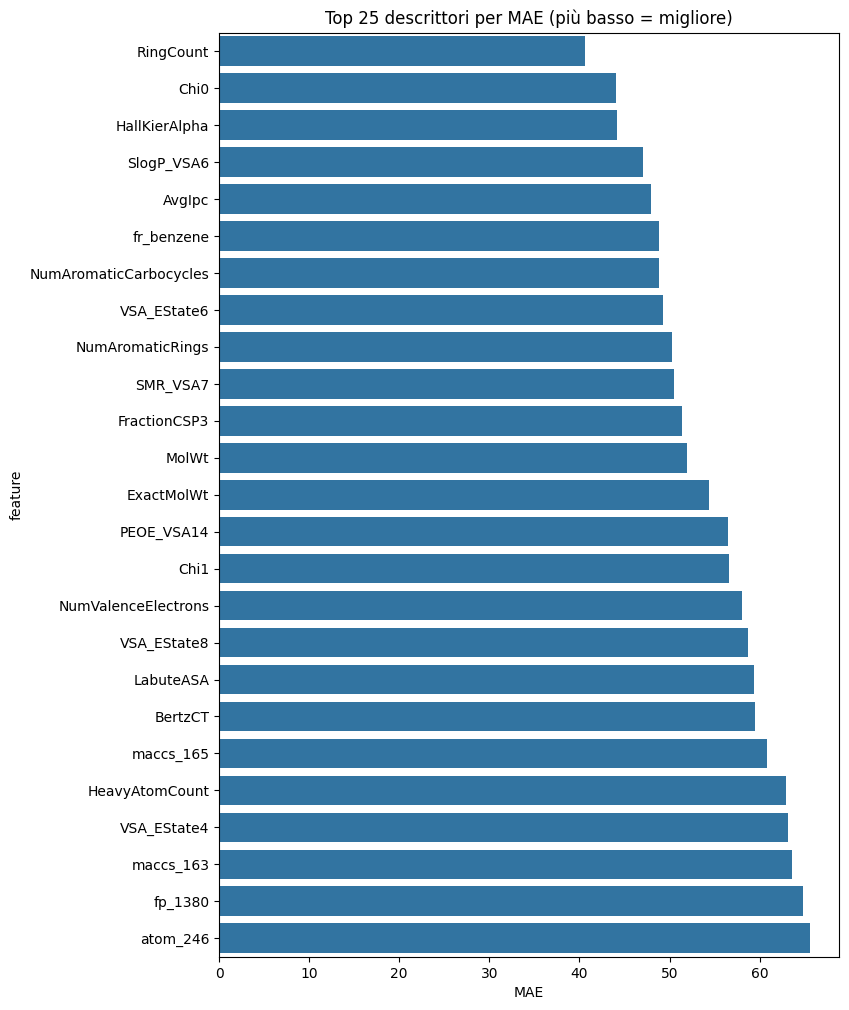

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,12))
sns.barplot(data=results_sorted.head(25), x="MAE", y="feature")
plt.title("Top 25 descrittori per MAE (più basso = migliore)")
plt.show()
